In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import xgi as xgi
import random as random
import time
import numpy as np
from scipy.special import binom
from collections import Counter
from itertools import combinations
from Configurational_model_HO import *
from HO_effective_degree import *

In [10]:
from numba import jit
from numba import njit, prange
from numba.typed import Dict
from numba.core import types
import scipy.sparse as sp

@jit(nopython=True)
def SIS_gillespie_temporal_evolution(N, beta1, beta2, mu, iters, edges, triangles, fixed_init, t_max, check_interval=100, variance_threshold=1e-4):
    I_runs = []
    S_runs=[]
    times_runs = []
    
    for h in range(iters):
        indddd = fixed_init[h]
        Infected = np.zeros(N)
        Infected[indddd] = 1

        t = 0
        times = [0]
        I = [np.sum(Infected)]
        S=[N-np.sum(Infected)]

        rate_vec = np.zeros(N)

        while t < t_max:
            # Update rate_vec
            rate_vec.fill(0)
            for edge in edges:
                v1, v2 = edge
                if Infected[v1] == 0 and Infected[v2] == 1:
                    rate_vec[v1] += beta1
                elif Infected[v2] == 0 and Infected[v1] == 1:
                    rate_vec[v2] += beta1

            for triangle in triangles:
                n1, n2, n3 = triangle
                if Infected[n1] == 0 and Infected[n2] == 1 and Infected[n3] == 1:
                    rate_vec[n1] += beta2
                elif Infected[n2] == 0 and Infected[n1] == 1 and Infected[n3] == 1:
                    rate_vec[n2] += beta2
                elif Infected[n3] == 0 and Infected[n1] == 1 and Infected[n2] == 1:
                    rate_vec[n3] += beta2

            rate_vec[Infected == 1] += mu

            total_rate = np.sum(rate_vec)
            if total_rate == 0:
                break

            delay = np.random.exponential(1.0 / total_rate)
            t += delay

            rr = np.random.random()
            cumulative_rate = 0
            for i in range(N):
                cumulative_rate += rate_vec[i] / total_rate
                if rr < cumulative_rate:
                    if Infected[i] == 1:
                        Infected[i] = 0
                    elif Infected[i] == 0:
                        Infected[i] = 1
                    break

            I.append(np.sum(Infected))
            S.append(N-np.sum(Infected))
            times.append(t)

            # Early stopping condition to check for stationarity
            if len(I) > check_interval:
                recent_values = np.array(I[-check_interval:])/N
                variance = np.var(recent_values)
                if variance < variance_threshold:
                    break
        
        I_runs.append(I)
        times_runs.append(times)
        S_runs.append(S)
    return times_runs, I_runs, S_runs

import numpy as np
import numba
from collections import defaultdict
from numba import njit, prange
from numba.typed import Dict
from numba.core import types
import scipy.sparse as sp
import random

def degree_per_node_list(hyperedges, nodes):
    """Optimized degree calculation with pre-allocated arrays"""
    max_order = max(len(edge) for edge in hyperedges)
    node_max = max(nodes)
    
    # Pre-allocate arrays instead of using defaultdicts
    degree_arrays = [np.zeros(node_max + 1, dtype=np.int32) for _ in range(max_order)]
    
    for edge in hyperedges:
        order_index = len(edge) - 1
        for node in edge:
            degree_arrays[order_index][node] += 1
    
    # Convert to dictionaries only for nodes in the list
    return [{node: degree_arrays[i][node] for node in nodes} for i in range(max_order)]

@njit
def perfect_hash_5d(s, i, x, y, z, max_dims):
    """Perfect hash function for 5D states - eliminates collisions"""
    return (s + 
            i * max_dims[0] + 
            x * max_dims[0] * max_dims[1] + 
            y * max_dims[0] * max_dims[1] * max_dims[2] + 
            z * max_dims[0] * max_dims[1] * max_dims[2] * max_dims[3])

@njit
def create_perfect_hash_map(states_array):
    """Create collision-free hash map with dimension bounds"""
    # Calculate max dimensions for perfect hashing
    max_dims = np.zeros(5, dtype=np.int64)
    for i in range(len(states_array)):
        for j in range(5):
            if states_array[i, j] > max_dims[j]:
                max_dims[j] = states_array[i, j]
    
    # Add 1 to include zero values
    max_dims += 1
    
    # Create hash map
    hash_map = numba.typed.Dict.empty(
        key_type=numba.types.int64,
        value_type=numba.types.int64
    )
    
    for i in range(len(states_array)):
        s, ii, x, y, z = states_array[i]
        hash_key = perfect_hash_5d(s, ii, x, y, z, max_dims)
        hash_map[hash_key] = i
    
    return hash_map, max_dims

@njit
def find_state_fast(s, i, x, y, z, hash_map, values_array, max_dims):
    """O(1) state lookup with perfect hashing"""
    if s < 0 or i < 0 or x < 0 or y < 0 or z < 0:
        return 0.0
    
    hash_key = perfect_hash_5d(s, i, x, y, z, max_dims)
    if hash_key in hash_map:
        return values_array[hash_map[hash_key]]
    return 0.0

@njit
def motifs_eff_degree_optimized(S_states, S_values, I_states, I_values, S_hash_map, I_hash_map, S_max_dims, I_max_dims):
    """Heavily optimized motif calculation with early exit and vectorization"""
    # Pre-allocate all variables
    SS = IS = II = 0.0
    SSS = ISS = ISI = SIS = III = 0.0
    ISS2=0.0
    I_S_S = II_S_S = I_S_SS = II_S_SS = 0.0
    I_S_SI = II_S_SI = I_S_I = II_S_I = II_S_II = 0.0
    
    max_s=0
    #print(max_s)
    # Process susceptible nodes
    for idx in range(len(S_states)):
        s, i, x, y, z = S_states[idx]
        if s>max_s: 
            max_s=s
        count = find_state_fast(s, i, x, y, z, S_hash_map, S_values, S_max_dims)
        
        if count < 1e-12:  # Skip negligible values
            continue
        #if count>N
        # Update basic counts
        SS += s * count
        IS += i * count
        SSS += x * count
        SIS += y * count
        ISI += z * count
        # Update complex motif counts
        I_S_S += i * s * count
        II_S_S += z * s * count
        I_S_SS += i * x * count
        II_S_SS += z * x * count
        I_S_SI += i * y * count
        II_S_SI += z * y * count
        
        if i > 0:
            I_S_I += i * (i-1) * count
            
        II_S_I += z * i * count
        if z > 0:
            II_S_II += z * (z-1) * count
    
    # Process infected nodes


    #print('I_S_S',I_S_S,'SS', SS)
    #print(max_s)
    # Calculate normalized frequencies
    


    for idx in range(len(I_states)):
        s, i, x, y, z = I_states[idx]
        count = find_state_fast(s, i, x, y, z, I_hash_map, I_values, I_max_dims)
        
        if count < 1e-12:
            continue

        #ISS += x * count
        
        II += i * count
        III += z * count
        ISS+= x * count

    # Safe division with individual calculations
    threshold_denom = 1e-12
    
    A = I_S_S / SS if SS > threshold_denom else 0.0
    B = II_S_S / SS if SS > threshold_denom else 0.0
    C = I_S_SS / SSS if SSS > threshold_denom else 0.0
    D = II_S_SS / SSS if SSS > threshold_denom else 0.0
    E = I_S_SI / SIS if SIS > threshold_denom else 0.0
    F = II_S_SI / SIS if SIS > threshold_denom else 0.0
    
    E2 = I_S_SI / ISS if ISS > threshold_denom else 0.0
    F2 = II_S_SI / ISS if ISS > threshold_denom else 0.0
    G = I_S_I / IS if IS > threshold_denom else 0.0
    H = II_S_I / IS if IS > threshold_denom else 0.0
    J = II_S_I / ISI if ISI > threshold_denom else 0.0
    K = II_S_II / ISI if ISI > threshold_denom else 0.0

    motifs1 = SS, IS, II, SSS, ISS, SIS, ISI, III 

    motifs2 = A, B, C, D, E, F, E2, F2,  G, H, J, K
    return motifs1,motifs2

@njit
def compute_derivatives_ultra_fast(S_states, S_values, I_states, I_values, 
                                 S_hash_map, I_hash_map, S_max_dims, I_max_dims,
                                 motifs, para):
    """Ultra-optimized derivative computation with perfect hashing"""
    b1, b2, gamma = para
    motifs1, motifs2 = motifs
    A, B, C, D, E, F, E2, F2,  G, H, J, K = motifs2
    
    dS_values = np.zeros_like(S_values)
    dI_values = np.zeros_like(I_values)
    
    # Precompute common terms
    b1_A_plus_b2_B = b1 * A + b2 * B
    b1_C_plus_b2_D = b1 * C + b2 * D
    b1_2E_plus_b2_2F = 2*(b1 * E + b2 *  F)
    b1_plus_b1_G_plus_b2_H = b1 + b1 * G + b2 * H
    b1_E_half_plus_b2_F_half = 0.5*(b1 * E2  + b2 * F2)
    b2_plus_b1_J_plus_b2_K = b2 + b1 * J + b2 *  K
    
    # Process S states with vectorization
    for idx in prange(len(S_states)):
        s, i, x, y, z = S_states[idx]
        S_curr = S_values[idx]
        
        
        I_curr = find_state_fast(s, i, x, y, z, I_hash_map, I_values, I_max_dims)
        
        # Batch neighbor lookups
        S1 = find_state_fast(s + 1, i - 1, x, y, z, S_hash_map, S_values, S_max_dims) if i > 0 else 0.0
        S2 = find_state_fast(s - 1, i + 1, x, y, z, S_hash_map, S_values, S_max_dims) if s > 0 else 0.0
        S3 = find_state_fast(s, i, x + 1, y - 1, z, S_hash_map, S_values, S_max_dims) if y > 0 else 0.0
        S4 = find_state_fast(s, i, x - 1, y + 1, z, S_hash_map, S_values, S_max_dims) if x > 0 else 0.0
        S5 = find_state_fast(s, i, x, y + 1, z - 1, S_hash_map, S_values, S_max_dims) if z > 0 else 0.0
        S6 = find_state_fast(s, i, x, y - 1, z + 1, S_hash_map, S_values, S_max_dims) if y > 0 else 0.0
        
               # Compute derivative
        dS_values[idx] = (-(b1 * i + b2 * z) * S_curr + gamma * I_curr +
                         (b1_A_plus_b2_B) * ((s + 1) * S1 - s * S_curr) +
                         (b1_C_plus_b2_D) * ((x + 1) * S3 - x * S_curr) +
                         (b1_2E_plus_b2_2F) * ((y + 1) * S5 - y * S_curr) +
                         gamma * (-(i + y + 2 * z) * S_curr + (i + 1) * S2 + (y + 1) * S4 + 2 * (z + 1) * S6))
    # Process I states similarly
    for idx in prange(len(I_states)):
        s, i, x, y, z = I_states[idx]
        I_curr = I_values[idx]
        
        S_curr = find_state_fast(s, i, x, y, z, S_hash_map, S_values, S_max_dims)
        
        # Batch neighbor lookups for I states
        I1 = find_state_fast(s + 1, i - 1, x, y, z, I_hash_map, I_values, I_max_dims) if i > 0 else 0.0
        I2 = find_state_fast(s - 1, i + 1, x, y, z, I_hash_map, I_values, I_max_dims) if s > 0 else 0.0
        I3 = find_state_fast(s, i, x + 1, y - 1, z, I_hash_map, I_values, I_max_dims) if y > 0 else 0.0
        I4 = find_state_fast(s, i, x - 1, y + 1, z, I_hash_map, I_values, I_max_dims) if x > 0 else 0.0
        I5 = find_state_fast(s, i, x, y + 1, z - 1, I_hash_map, I_values, I_max_dims) if z > 0 else 0.0
        I6 = find_state_fast(s, i, x, y - 1, z + 1, I_hash_map, I_values, I_max_dims) if y > 0 else 0.0
        
        
        dI_values[idx] = ((b1 * i + b2 * z) * S_curr - gamma * I_curr +
                         (b1_plus_b1_G_plus_b2_H) * ((s + 1) * I1 - s * I_curr) +
                         (b1_E_half_plus_b2_F_half) * ((x + 1) * I3 - x * I_curr) +
                         (b2_plus_b1_J_plus_b2_K) * ((y + 1) * I5 - y * I_curr) +
                         gamma * (-(i + y + 2 * z) * I_curr + (i + 1) * I2 + (y + 1) * I4 + 2 * (z + 1) * I6))
    
    
    return dS_values, dI_values

@njit
def compute_derivatives_ultra_fast(S_states, S_values, I_states, I_values, 
                                 S_hash_map, I_hash_map, S_max_dims, I_max_dims,
                                 motifs, para):
    """Ultra-optimized derivative computation with perfect hashing"""
    b1, b2, gamma = para
    motifs1, motifs2 = motifs
    A, B, C, D, E, F, E2, F2,  G, H, J, K = motifs2
    
    dS_values = np.zeros_like(S_values)
    dI_values = np.zeros_like(I_values)
    
    # Precompute common terms
    b1_A_plus_b2_B = b1 * A + b2 * B
    b1_C_plus_b2_D = b1 * C + b2 * D
    b1_2E_plus_b2_2F = 2*(b1 * E + b2 *  F)
    b1_plus_b1_G_plus_b2_H = b1 + b1 * G + b2 * H
    b1_E_half_plus_b2_F_half = 0.5*(b1 * E2  + b2 * F2)
    b2_plus_b1_J_plus_b2_K = b2 + b1 * J + b2 *  K
    
    # Process S states with vectorization
    for idx in prange(len(S_states)):
        s, i, x, y, z = S_states[idx]
        S_curr = S_values[idx]
        
        
        I_curr = find_state_fast(s, i, x, y, z, I_hash_map, I_values, I_max_dims)
        
        # Batch neighbor lookups
        S1 = find_state_fast(s + 1, i - 1, x, y, z, S_hash_map, S_values, S_max_dims) if i > 0 else 0.0
        S2 = find_state_fast(s - 1, i + 1, x, y, z, S_hash_map, S_values, S_max_dims) if s > 0 else 0.0
        S3 = find_state_fast(s, i, x + 1, y - 1, z, S_hash_map, S_values, S_max_dims) if y > 0 else 0.0
        S4 = find_state_fast(s, i, x - 1, y + 1, z, S_hash_map, S_values, S_max_dims) if x > 0 else 0.0
        S5 = find_state_fast(s, i, x, y + 1, z - 1, S_hash_map, S_values, S_max_dims) if z > 0 else 0.0
        S6 = find_state_fast(s, i, x, y - 1, z + 1, S_hash_map, S_values, S_max_dims) if y > 0 else 0.0
        
               # Compute derivative
        dS_values[idx] = (-(b1 * i + b2 * z) * S_curr + gamma * I_curr +
                         (b1_A_plus_b2_B) * ((s + 1) * S1 - s * S_curr) +
                         (b1_C_plus_b2_D) * ((x + 1) * S3 - x * S_curr) +
                         (b1_2E_plus_b2_2F) * ((y + 1) * S5 - y * S_curr) +
                         gamma * (-(i + y + 2 * z) * S_curr + (i + 1) * S2 + (y + 1) * S4 + 2 * (z + 1) * S6))
    # Process I states similarly
    for idx in prange(len(I_states)):
        s, i, x, y, z = I_states[idx]
        I_curr = I_values[idx]
        
        S_curr = find_state_fast(s, i, x, y, z, S_hash_map, S_values, S_max_dims)
        
        # Batch neighbor lookups for I states
        I1 = find_state_fast(s + 1, i - 1, x, y, z, I_hash_map, I_values, I_max_dims) if i > 0 else 0.0
        I2 = find_state_fast(s - 1, i + 1, x, y, z, I_hash_map, I_values, I_max_dims) if s > 0 else 0.0
        I3 = find_state_fast(s, i, x + 1, y - 1, z, I_hash_map, I_values, I_max_dims) if y > 0 else 0.0
        I4 = find_state_fast(s, i, x - 1, y + 1, z, I_hash_map, I_values, I_max_dims) if x > 0 else 0.0
        I5 = find_state_fast(s, i, x, y + 1, z - 1, I_hash_map, I_values, I_max_dims) if z > 0 else 0.0
        I6 = find_state_fast(s, i, x, y - 1, z + 1, I_hash_map, I_values, I_max_dims) if y > 0 else 0.0
        
        
        dI_values[idx] = ((b1 * i + b2 * z) * S_curr - gamma * I_curr +
                         (b1_plus_b1_G_plus_b2_H) * ((s + 1) * I1 - s * I_curr) +
                         (b1_E_half_plus_b2_F_half) * ((x + 1) * I3 - x * I_curr) +
                         (b2_plus_b1_J_plus_b2_K) * ((y + 1) * I5 - y * I_curr) +
                         gamma * (-(i + y + 2 * z) * I_curr + (i + 1) * I2 + (y + 1) * I4 + 2 * (z + 1) * I6))
    
    
    return dS_values, dI_values

@njit
def adaptive_timestep(S_values, I_values, dS_values, dI_values, dt_current, 
                     tolerance=1e-6, max_dt=0.01, min_dt=1e-8):
    """Adaptive timestep control for numerical stability"""
    # Calculate relative changes
    max_rel_change = 0.0
    
    for i in range(len(S_values)):
        if S_values[i] > tolerance:
            rel_change = abs(dS_values[i] * dt_current / S_values[i])
            if rel_change > max_rel_change:
                max_rel_change = rel_change
    
    for i in range(len(I_values)):
        if I_values[i] > tolerance:
            rel_change = abs(dI_values[i] * dt_current / I_values[i])
            if rel_change > max_rel_change:
                max_rel_change = rel_change
    
    # Adjust timestep
    if max_rel_change > 0.1:  # Too fast
        dt_new = max(dt_current * 0.5, min_dt)
    elif max_rel_change < 0.01:  # Too slow
        dt_new = min(dt_current * 1.2, max_dt)
    else:
        dt_new = dt_current
    
    return dt_new

def dict_to_arrays_optimized(state_dict):
    """Optimized dictionary to array conversion"""
    if not state_dict:
        return np.empty((0, 5), dtype=np.int32), np.empty(0, dtype=np.float64)
    
    n_states = len(state_dict)
    states_array = np.empty((n_states, 5), dtype=np.int32)
    values_array = np.empty(n_states, dtype=np.float64)
    
    for i, (state, value) in enumerate(state_dict.items()):
        states_array[i] = state
        values_array[i] = value
    
    return states_array, values_array

def X_si_xyz_from_degree_list_fast(degree_node, node_list):
    """Fast state space generation"""
    S_si_xyz = {}
    I_si_xyz = {}
    
    for node in node_list:
        k1 = degree_node[1].get(node, 0)
        k2 = degree_node[2].get(node, 0)
        
        for i in range(k1 + 1):
            s = k1 - i
            for j in range(k2 + 1):
                for j_ in range(j + 1):
                    x = k2 - j
                    y = j - j_
                    z = j_
                    key = (s, i, x, y, z)
                    S_si_xyz[key] = 0
                    I_si_xyz[key] = 0
    
    return S_si_xyz, I_si_xyz


def initial_states_fast(initial_infec, node_list, degree_node, edges_node):
    """Calculate initial states - no changes needed as this runs once"""
    state_node = {
        node: 'I' if node in initial_infec else 'S' 
        for node in node_list
    }
    
    S_si_xyz, I_si_xyz = X_si_xyz_from_degree_list(degree_node, node_list)
    
    for state in S_si_xyz:
        S_si_xyz[state] = 0
    for state in I_si_xyz:
        I_si_xyz[state] = 0
    
    for node in node_list:
        s = i = x = y = z = 0
        
        for neigh in edges_node[node]:
            if len(neigh) == 1:
                v1 = neigh[0]
                if state_node[v1] == 'I':
                    i += 1
                elif state_node[v1] == 'S':
                    s += 1
            elif len(neigh) == 2:
                v1, v2 = neigh[0], neigh[1]
                
                if state_node[v1] == 'S' and state_node[v2] == 'S':
                    x += 1
                elif (state_node[v1] == 'S' and state_node[v2] == 'I') or (state_node[v2] == 'S' and state_node[v1] == 'I'):
                    y += 1
                elif state_node[v1] == 'I' and state_node[v2] == 'I':
                    z += 1
        
        neigh_state = (s, i, x, y, z)
        
        if state_node[node] == 'I':
            I_si_xyz[neigh_state] = I_si_xyz.get(neigh_state, 0) + 1
        elif state_node[node] == 'S':
            S_si_xyz[neigh_state] = S_si_xyz.get(neigh_state, 0) + 1
    
    return state_node, S_si_xyz, I_si_xyz

def X_si_xyz_from_degree_list(degree_node, node_list):
    """
    Given degree information (as from `degree_per_node_list`) and a list of nodes,
    returns dictionaries S_si_xyz and I_si_xyz.
    """
    S_si_xyz = {}
    I_si_xyz = {}

    for node in node_list:
        k1 = degree_node[1][node]  # degree from pairwise (order-2) interactions
        k2 = degree_node[2][node]  # degree from 3-node (order-3) interactions

        for i in range(k1 + 1):
            s = k1 - i
            for j in range(k2 + 1):
                for j_ in range(j + 1):
                    x = k2 - j
                    y = j - j_
                    z = j_
                    key = (s, i, x, y, z)
                    if key not in S_si_xyz:
                        S_si_xyz[key] = 0
                        I_si_xyz[key] = 0

    return S_si_xyz, I_si_xyz

def odeint_effective_degree_HO_ultra_optimized(para, hyper_edge_list, N, 
                                              initial_infected=None, T=15, 
                                              steps_ode=2000, adaptive_dt=True,
                                              progress_callback=None, complete=True):
    """
    Ultra-optimized version with perfect hashing, adaptive timesteps, and vectorization.
    
    Key optimizations:
    1. Perfect hash functions eliminate collisions
    2. Parallel processing with prange
    3. Adaptive timestep control
    4. Vectorized operations
    5. Early exit conditions
    6. Memory-efficient data structures
    """
    dt_initial = T / steps_ode
    node_list = list(range(1, N + 1))
    
    # Optimized hyperedge processing
    edges_node = defaultdict(list)
    for edge in hyper_edge_list:
        edge_list = list(edge)
        for node in edge:
            neighbors = [n for n in edge_list if n != node]
            edges_node[int(node)].append(neighbors)
    
    # Convert to regular dict for better performance
    edges_node = dict(edges_node)
    for node in node_list:
        if node not in edges_node:
            edges_node[node] = []
    
    # Optimized degree calculation
    degree_node = degree_per_node_list(hyper_edge_list, node_list)
    
    # Initialize infected nodes
    if isinstance(initial_infected, int):
        initial_infected = random.sample(node_list, k=initial_infected)
    elif initial_infected is None:
        initial_infected = []
    
    # Calculate initial states using the helper functions
    state_node, S_si_xyz, I_si_xyz = initial_states_fast(initial_infected, node_list, degree_node, edges_node)
    #print(len(S_si_xyz))
    #print('-------')
    #print(len(I_si_xyz))
    # Convert to optimized arrays
    S_states, S_values = dict_to_arrays_optimized(S_si_xyz)
    I_states, I_values = dict_to_arrays_optimized(I_si_xyz)
    
    # Create perfect hash maps
    S_hash_map, S_max_dims = create_perfect_hash_map(S_states)
    I_hash_map, I_max_dims = create_perfect_hash_map(I_states)
    
    # Convert parameters
    para_array = np.array(para, dtype=np.float64)
    
    # Initialize time series
    times = [0.0]
    S_t = [float(N - len(initial_infected))]
    I_t = [float(len(initial_infected))]
    
    # Integration with adaptive timestep
    current_time = 0.0
    dt = dt_initial
    step = 0
    max_steps = steps_ode * 10  # Allow more steps with adaptive dt
    Motifs_time=[]
    print("Starting ultra-optimized integration...")
    
    while current_time < T and step < max_steps:
        # Calculate motifs
        motifs = motifs_eff_degree_optimized(S_states, S_values, I_states, I_values, S_hash_map, I_hash_map, S_max_dims, I_max_dims)

        motifs1, motifs2 = motifs
        
        # Compute derivatives
        dS_values, dI_values = compute_derivatives_ultra_fast(
            S_states, S_values, I_states, I_values,
            S_hash_map, I_hash_map, S_max_dims, I_max_dims,
            motifs, para_array
        )
        
        # Adaptive timestep
        if adaptive_dt and step > 0:
            dt = adaptive_timestep(S_values, I_values, dS_values, dI_values, dt)
        
        # Ensure we don't overshoot
        if current_time + dt > T:
            dt = T - current_time
        
        # Update states
        S_values = S_values + dt * dS_values
        I_values = I_values +  dt * dI_values
        
        current_time += dt
        step += 1
        

        S_total = np.sum(S_values)
        I_total = np.sum(I_values)
        
        times.append(current_time)
        S_t.append(S_total)
        I_t.append(I_total)
        #Motifs_time.append(motifs1)
            # Progress reporting
        if progress_callback:
            progress_callback(current_time / T * 100)
        elif step % (max_steps // 20) == 0:
            print(f"Progress: {current_time/T*100:.1f}% (t={current_time:.3f}, dt={dt:.6f})")
            
            # Early termination checks
        if I_total < 1e-6:  # Infection died out
            #print("Infection died out, terminating early")
            break
        if I_total > N * 1.1:  # Numerical instability
            #print("Numerical instability detected, terminating")
            return []
    
    print(f"Integration completed in {step} steps")
    return times, S_t, I_t#, Motifs_time

# Backward compatibility wrapper
def odeint_effective_degree_HO_optimized(para, hyper_edge_list, N, initial_infected=None, 
                                       T=15, steps_ode=2000, use_numba=True, use_fast_derivatives=True):
    """Wrapper for backward compatibility"""
    return odeint_effective_degree_HO_ultra_optimized(
        para, hyper_edge_list, N, initial_infected, T, steps_ode, 
        adaptive_dt=use_fast_derivatives
    )


"""
High-Performance Epidemiological Simulation on Hypergraphs
==========================================================

This module implements a Numba-optimized epidemiological simulation using hypergraphs
to model disease spread through higher-order interactions (groups of 2+ individuals).

The model uses a degree-based mean-field approach with JIT compilation for maximum
performance on SIS (Susceptible-Infected-Susceptible) dynamics.

Key Performance Features:
- Numba JIT compilation for critical functions
- Optimized data structures using typed dictionaries and arrays
- Parallel processing where applicable
- Memory-efficient degree-based state tracking
- Adaptive timestep integration with vectorized operations

Author: [Your Name]
Date: [Date]
"""

import numpy as np
import numba
from collections import defaultdict
from numba import njit, prange, types
from numba.typed import Dict, List
import scipy.sparse as sp
import random


# =============================================================================
# NUMBA-OPTIMIZED DEGREE CALCULATIONS
# =============================================================================

@njit
def _count_degrees_fast(edges_array, nodes_array, max_order):
    """
    Numba-optimized degree counting for hyperedges.
    
    Parameters:
    -----------
    edges_array : List[array]
        List of numpy arrays, each containing nodes in a hyperedge
    nodes_array : array
        Array of node IDs to process
    max_order : int
        Maximum hyperedge size
    
    Returns:
    --------
    array
        3D array: degree_counts[order][node] = degree for that order
    """
    node_max = np.max(nodes_array)
    degree_counts = np.zeros((max_order, node_max + 1), dtype=np.int32)
    
    for i in range(len(edges_array)):
        edge = edges_array[i]
        order_index = len(edge) - 1
        if order_index < max_order:
            for j in range(len(edge)):
                node = edge[j]
                degree_counts[order_index][node] += 1
    
    return degree_counts


def degree_per_node_list_optimized(hyperedges, nodes):
    """
    Optimized degree calculation using Numba compilation.
    
    Parameters:
    -----------
    hyperedges : list
        List of hyperedges (each is a list/tuple of node IDs)
    nodes : list
        List of all node IDs
        
    Returns:
    --------
    list of dicts
        Degree information for each hyperedge order
    """
    if not hyperedges:
        return [{}] * 3  # Return empty dicts for orders 0, 1, 2
    
    # Convert to Numba-compatible format
    edges_typed = List()
    max_order = 0
    
    for edge in hyperedges:
        edge_array = np.array(list(edge), dtype=np.int32)
        edges_typed.append(edge_array)
        max_order = max(max_order, len(edge))
    
    nodes_array = np.array(nodes, dtype=np.int32)
    
    # Use Numba-optimized counting
    degree_counts = _count_degrees_fast(edges_typed, nodes_array, max_order)
    
    # Convert back to dictionary format
    result = []
    for order in range(max_order):
        order_dict = {node: int(degree_counts[order][node]) for node in nodes}
        result.append(order_dict)
    
    return result


# =============================================================================
# NUMBA-OPTIMIZED CORE COMPUTATIONS
# =============================================================================

@njit
def compute_derivatives_numba(S_states, S_values, I_states, I_values,
                             I_prob, Z_prob, b1, b2, gamma,
                             dS_out, dI_out):
    """
    Ultra-fast Numba-compiled derivative computation.
    
    Parameters:
    -----------
    S_states, I_states : array
        State tuples (k1, k2) for each population
    S_values, I_values : array  
        Population values for each state
    I_prob, Z_prob : float
        Infection probabilities
    b1, b2, gamma : float
        Model parameters
    dS_out, dI_out : array (output)
        Arrays to store computed derivatives
    """
    n_states = len(S_values)
    
    # Vectorized computation of derivatives
    for i in prange(n_states):
        k1, k2 = S_states[i, 0], S_states[i, 1]
        S_curr = S_values[i]
        I_curr = I_values[i]
        
        # Infection rate calculation
        infection_rate = b1 * I_prob * k1 + b2 * Z_prob * k2
        
        # Update derivatives
        dS_out[i] = -infection_rate * S_curr + gamma * I_curr
        dI_out[i] = infection_rate * S_curr - gamma * I_curr

@njit
def new_inf(S_states, S_values, I_states, I_values,
                             I_prob, Z_prob, b1, b2, gamma,
                             dS_out, dI_out):
    """
    Ultra-fast Numba-compiled derivative computation.
    
    Parameters:
    -----------
    S_states, I_states : array
        State tuples (k1, k2) for each population
    S_values, I_values : array  
        Population values for each state
    I_prob, Z_prob : float
        Infection probabilities
    b1, b2, gamma : float
        Model parameters
    dS_out, dI_out : array (output)
        Arrays to store computed derivatives
    """
    n_states = len(S_values)
    dI_new = np.zeros(len(dI_out))
    # Vectorized computation of derivatives
    for i in prange(n_states):
        k1, k2 = S_states[i, 0], S_states[i, 1]
        S_curr = S_values[i]
        I_curr = I_values[i]
        
        # Infection rate calculation
        infection_rate = b1 * I_prob * k1 + b2 * Z_prob * k2
        
        # Update derivatives
        dI_new[i] = infection_rate * S_curr - gamma * I_curr
    return dI_new


@njit
def calculate_ABCDE_numba(states, S_values):
    """
    Numba-optimized calculation of mathematical constants.
    
    Parameters:
    -----------
    states : array
        State tuples (k1, k2)
    S_values : array
        Susceptible populations for each state
        
    Returns:
    --------
    tuple
        (A, B, C, D, E) constants
    """
    A, B, C, D, E = 0.0, 0.0, 0.0, 0.0, 0.0
    
    for i in range(len(states)):
        k1, k2 = states[i, 0], states[i, 1]
        S_curr = S_values[i]
        
        A += k1 * S_curr
        B += k2 * S_curr  
        C += k1 * k2 * S_curr
        
        if k1 > 0:
            D += k1 * (k1 - 1) * S_curr
        if k2 > 0:
            E += k2 * (k2 - 1) * S_curr
    
    return A, B, C, D, E


@njit
def update_populations_numba(S_values, I_values, dS_values, dI_values, dt):
    """
    Numba-optimized population update with bounds checking.
    
    Parameters:
    -----------
    S_values, I_values : array
        Current population values
    dS_values, dI_values : array
        Derivative values
    dt : float
        Timestep
    """
    for i in prange(len(S_values)):
        # Euler step with non-negativity constraint
        S_new = S_values[i] + dt * dS_values[i]
        I_new = I_values[i] + dt * dI_values[i]
        
        S_values[i] = max(0.0, S_new)
        I_values[i] = max(0.0, I_new)


@njit
def adaptive_timestep_numba(S_values, I_values, dS_values, dI_values, 
                           dt_current, tolerance, max_dt, min_dt):
    """
    Numba-optimized adaptive timestep calculation.
    """
    max_rel_change = 0.0
    
    for i in range(len(S_values)):
        if S_values[i] > tolerance:
            rel_change = abs(dS_values[i] * dt_current / S_values[i])
            if rel_change > max_rel_change:
                max_rel_change = rel_change
    
    for i in range(len(I_values)):
        if I_values[i] > tolerance:
            rel_change = abs(dI_values[i] * dt_current / I_values[i])
            if rel_change > max_rel_change:
                max_rel_change = rel_change
    
    # Adjust timestep
    if max_rel_change > 0.1:
        return max(dt_current * 0.5, min_dt)
    elif max_rel_change < 0.01:
        return min(dt_current * 1.2, max_dt)
    else:
        return dt_current


@njit 
def compute_motif_derivatives_numba(SI, II, SSI, SII, III,
                                   I_prob, Z_prob, Y_prob,
                                   b1, b2, gamma, C, D, E):
    """
    Numba-compiled motif dynamics computation.
    
    Returns:
    --------
    tuple
        (dSI, dII, dSSI, dSII, dIII) - motif derivatives
    """
    # Pairwise motif dynamics
    dSI = (gamma * 2 * II - (gamma + b1) * SI + 
           (1 - 2 * I_prob) * (b1 * I_prob * D + b2 * Z_prob * C))
    dII = (-2 * gamma * II + b1 * SI + 
           I_prob * (b1 * I_prob * D + b2 * Z_prob * C))
    
    # 3-way motif dynamics  
    dSSI = (gamma * (2 * SII - SSI) + 
            (1 - Z_prob - 2 * Y_prob) * (b1 * I_prob * C + b2 * Z_prob * E))
    dSII = (3 * gamma * III - (2 * gamma + b2) * SII + 
            (Y_prob - Z_prob) * (b1 * I_prob * C + b2 * Z_prob * E))
    dIII = (-3 * gamma * III + b2 * SII + 
            Z_prob * (b1 * I_prob * C + b2 * Z_prob * E))
    
    return dSI, dII, dSSI, dSII, dIII


# =============================================================================
# OPTIMIZED DATA STRUCTURES
# =============================================================================

class OptimizedStateTracker:
    """
    High-performance state tracking using numpy arrays instead of dictionaries.
    
    This class converts the dictionary-based state tracking to array-based
    for maximum Numba compatibility and performance.
    """
    
    def __init__(self, degree_combinations):
        """
        Initialize with all possible degree combinations.
        
        Parameters:
        -----------
        degree_combinations : list of tuples
            All unique (k1, k2) degree combinations in the system
        """
        self.states = np.array(degree_combinations, dtype=np.int32)
        self.n_states = len(degree_combinations)
        
        # Create mapping from (k1, k2) tuple to array index
        self.state_to_idx = {tuple(state): i for i, state in enumerate(self.states)}
        
        # Initialize population arrays
        self.S_values = np.zeros(self.n_states, dtype=np.float64)
        self.I_values = np.zeros(self.n_states, dtype=np.float64)
        
        # Pre-allocate derivative arrays
        self.dS_values = np.zeros(self.n_states, dtype=np.float64)
        self.dI_values = np.zeros(self.n_states, dtype=np.float64)
    
    def set_population(self, k1, k2, S_pop, I_pop):
        """Set population for a specific degree combination."""
        idx = self.state_to_idx.get((k1, k2))
        if idx is not None:
            self.S_values[idx] = S_pop
            self.I_values[idx] = I_pop
    
    def get_total_populations(self):
        """Get total S and I populations."""
        return np.sum(self.S_values), np.sum(self.I_values)
    
    def compute_derivatives(self, I_prob, Z_prob, b1, b2, gamma):
        """Compute derivatives using Numba-optimized function."""
        compute_derivatives_numba(
            self.states, self.S_values, self.states, self.I_values,
            I_prob, Z_prob, b1, b2, gamma,
            self.dS_values, self.dI_values
        )
    
    def update_populations(self, dt):
        """Update populations using computed derivatives."""
        update_populations_numba(
            self.S_values, self.I_values, 
            self.dS_values, self.dI_values, dt
        )
    
    def calculate_constants(self):
        """Calculate mathematical constants A, B, C, D, E."""
        return calculate_ABCDE_numba(self.states, self.S_values)


# =============================================================================
# INITIALIZATION AND SETUP
# =============================================================================

def setup_initial_conditions_optimized(initial_infected, node_list, degree_node):
    """
    Optimized initial condition setup using vectorized operations.
    
    Parameters:
    -----------
    initial_infected : list
        Initially infected node IDs
    node_list : list
        All node IDs
    degree_node : list of dicts
        Degree information
    
    Returns:
    --------
    tuple
        (state_tracker, motifs_init) - optimized state tracking and initial motifs
    """
    # Collect all unique degree combinations
    degree_combinations = set()
    node_degrees = {}
    
    for node in node_list:
        k1 = degree_node[1].get(node, 0) if len(degree_node) > 1 else 0
        k2 = degree_node[2].get(node, 0) if len(degree_node) > 2 else 0
        degree_combo = (k1, k2)
        degree_combinations.add(degree_combo)
        node_degrees[node] = degree_combo
    
    # Initialize optimized state tracker
    state_tracker = OptimizedStateTracker(list(degree_combinations))
    
    # Count initial populations and motifs
    infected_set = set(initial_infected)
    motif_counts = {'SS': 0, 'SI': 0, 'SSS': 0, 'SSI': 0}
    degree_populations = defaultdict(lambda: {'S': 0, 'I': 0})
    
    for node in node_list:
        k1, k2 = node_degrees[node]
        
        if node in infected_set:
            degree_populations[(k1, k2)]['I'] += 1
            motif_counts['SI'] += k1
            motif_counts['SSI'] += k2
        else:
            degree_populations[(k1, k2)]['S'] += 1
            motif_counts['SS'] += k1
            motif_counts['SSS'] += k2
    
    # Set populations in state tracker
    for (k1, k2), pops in degree_populations.items():
        state_tracker.set_population(k1, k2, pops['S'], pops['I'])
    
    motifs_init = [motif_counts['SS'], motif_counts['SI'], 
                   motif_counts['SSS'], motif_counts['SSI']]
    
    return state_tracker, motifs_init


# =============================================================================
# MAIN OPTIMIZED SIMULATION
# =============================================================================

def odeint_effective_degree_HO_numba_optimized(para, hyper_edge_list, N, 
                                              initial_infected=None, T=15, 
                                              steps_ode=2000, adaptive_dt=True,
                                              progress_callback=False):
    """
    Numba-optimized main simulation with maximum performance.
    
    This version uses:
    - JIT-compiled critical functions
    - Array-based data structures
    - Vectorized operations
    - Optimized memory access patterns
    - Parallel processing where applicable
    
    Parameters:
    -----------
    para : tuple
        (b1, b2, gamma) - model parameters
    hyper_edge_list : list
        Hyperedges defining the network structure
    N : int
        Total number of nodes
    initial_infected : int or list
        Initial infection specification
    T : float
        Simulation time
    steps_ode : int
        Number of integration steps
    adaptive_dt : bool
        Use adaptive timestep control
    progress_callback : callable
        Progress reporting function
    
    Returns:
    --------
    tuple
        (times, S_t, I_t, Motifs_time) - simulation results
    """
    #print("Starting Numba-optimized simulation...")
    
    # Parameter setup
    b1, b2, gamma = para
    dt_initial = T / steps_ode
    node_list = list(range(1, N + 1))
    
    # Handle initial infection
    if isinstance(initial_infected, int):
        initial_infected = random.sample(node_list, k=initial_infected)
    elif initial_infected is None:
        initial_infected = []
    
    # Optimized degree calculation
    #print("Computing degrees with Numba optimization...")
    degree_node = degree_per_node_list_optimized(hyper_edge_list, node_list)
    
    # Ensure we have at least 3 orders (0, 1, 2) for compatibility
    while len(degree_node) < 3:
        degree_node.append({node: 0 for node in node_list})
    
    # Setup optimized initial conditions
    #print("Initializing optimized state tracking...")
    state_tracker, motifs_init = setup_initial_conditions_optimized(
        initial_infected, node_list, degree_node
    )
    
    SS_0, SI_0, SSS_0, SSI_0 = motifs_init
    #print('Adaptative time', adaptive_dt)
    # Pre-allocate all time series arrays for better performance
    max_steps = steps_ode * 10
    times = np.zeros(max_steps + 1)
    S_t = np.zeros(max_steps + 1)  
    I_t = np.zeros(max_steps + 1)
    SS_t = np.zeros(max_steps + 1)
    SI_t = np.zeros(max_steps + 1)
    II_t = np.zeros(max_steps + 1)
    SSS_t = np.zeros(max_steps + 1)
    SSI_t = np.zeros(max_steps + 1)
    SII_t = np.zeros(max_steps + 1)
    III_t = np.zeros(max_steps + 1)
    
    # Initialize first values
    S_total, I_total = state_tracker.get_total_populations()
    times[0] = 0.0
    S_t[0] = S_total
    I_t[0] = I_total
    SS_t[0] = SS_0
    SI_t[0] = SI_0
    II_t[0] = 0
    SSS_t[0] = SSS_0  
    SSI_t[0] = SSI_0
    SII_t[0] = 0
    III_t[0] = 0
    
    # Constants for motif conservation
    total_links = SS_0 + SI_0
    total_groups = SSS_0 + SSI_0
    
    # Integration parameters
    current_time = 0.0
    dt = dt_initial
    step = 0
    
    #print("Starting optimized integration loop...")
    
    # Main integration loop with Numba optimization
    while current_time < T and step < max_steps - 1:
        
        # Calculate mathematical constants using optimized function
        A, B, C, D, E = state_tracker.calculate_constants()
        
        # Compute infection probabilities with safety checks
        I_prob = SI_t[step] / A if A > 1e-12 else 0.0
        Z_prob = SII_t[step] / B if B > 1e-12 else 0.0
        Y_prob = 2 * SSI_t[step] / B if B > 1e-12 else 0.0
        
        # Current motif values
        SI = SI_t[step]
        II = II_t[step]
        SSI = SSI_t[step]
        SII = SII_t[step]
        III = III_t[step]
        
        # Compute motif derivatives using Numba
        dSI, dII, dSSI, dSII, dIII = compute_motif_derivatives_numba(
            SI, II, SSI, SII, III, I_prob, Z_prob, Y_prob,
            b1, b2, gamma, C, D, E
        )
        
        # Compute degree-based population derivatives
        state_tracker.compute_derivatives(I_prob, Z_prob, b1, b2, gamma)
        
        # Adaptive timestep control
        if adaptive_dt and step > 0:
            dt = adaptive_timestep_numba(
                state_tracker.S_values, state_tracker.I_values,
                state_tracker.dS_values, state_tracker.dI_values,
                dt, 1e-6, 0.01, 1e-8
            )
        
        # Ensure we don't overshoot
        if current_time + dt > T:
            dt = T - current_time
        
        # Update populations
        state_tracker.update_populations(dt)
        
        # Update time and step
        current_time += dt
        step += 1
        
        # Store results
        S_total, I_total = state_tracker.get_total_populations()
        times[step] = current_time
        S_t[step] = S_total
        I_t[step] = I_total
        
        # Update motifs
        SI_t[step] = SI_t[step-1] + dt * dSI
        II_t[step] = II_t[step-1] + dt * dII
        SS_t[step] = total_links - II_t[step] - SI_t[step]
        
        SSI_t[step] = SSI_t[step-1] + dt * dSSI
        SII_t[step] = SII_t[step-1] + dt * dSII
        III_t[step] = III_t[step-1] + dt * dIII
        SSS_t[step] = total_groups - SSI_t[step] - SII_t[step] - III_t[step]
        
        # Progress reporting
        if progress_callback and step % 100 == 0:
            progress_callback(current_time / T * 100)
        elif progress_callback and step % (max_steps // 20) == 0:
            print(f"Progress: {current_time/T*100:.1f}% "
                  f"(t={current_time:.3f}, dt={dt:.6f}, step={step})")
        
        # Early termination
        if I_total < 1e-8:
            #print("Infection died out, terminating early")
            break
        if I_total > N * 1.2:
            #print("Numerical instability detected")
            break
    
    # Trim arrays to actual length
    actual_length = step + 1
    times_final = times[:actual_length].copy()
    S_t_final = S_t[:actual_length].copy()
    I_t_final = I_t[:actual_length].copy()
    
    Motifs_time = [
        SS_t[:actual_length].copy(),
        SI_t[:actual_length].copy(),
        II_t[:actual_length].copy(),
        SSS_t[:actual_length].copy(),
        SSI_t[:actual_length].copy(),
        SII_t[:actual_length].copy(),
        III_t[:actual_length].copy()
    ]
    
    #print(f"Numba-optimized integration completed in {step} steps")
    #print(f"Final populations: S={S_t_final[-1]:.1f}, I={I_t_final[-1]:.1f}")
    
    return times_final, S_t_final, I_t_final, Motifs_time


# =============================================================================
# BACKWARD COMPATIBILITY AND CONVENIENCE FUNCTIONS
# =============================================================================

def odeint_compact_effective_degree_HO_optimized(para, hyper_edge_list, N, 
                                                initial_infected=None, T=15, 
                                                steps_ode=2000, use_numba=True, 
                                                use_fast_derivatives=True, progress_callback=False):
    """
    Optimized wrapper with automatic Numba usage.
    
    This function automatically uses the Numba-optimized version for
    maximum performance while maintaining backward compatibility.
    """
    if use_numba:
        return odeint_effective_degree_HO_numba_optimized(
            para, hyper_edge_list, N, initial_infected, T, steps_ode,
            adaptive_dt=use_fast_derivatives,progress_callback=progress_callback
        )
    else:
        # Fallback to original implementation if needed
        print("Warning: Numba optimization disabled, using slower implementation")
        # Could implement non-Numba fallback here
        return odeint_effective_degree_HO_numba_optimized(
            para, hyper_edge_list, N, initial_infected, T, steps_ode,
            adaptive_dt=use_fast_derivatives,progress_callback=progress_callback
        )

In [11]:
@njit
def new_inf(S_states, S_values, I_states, I_values,
                             I_prob, Z_prob, b1, b2, gamma,
                             dS_out, dI_out):
    """
    Ultra-fast Numba-compiled derivative computation.
    
    Parameters:
    -----------
    S_states, I_states : array
        State tuples (k1, k2) for each population
    S_values, I_values : array  
        Population values for each state
    I_prob, Z_prob : float
        Infection probabilities
    b1, b2, gamma : float
        Model parameters
    dS_out, dI_out : array (output)
        Arrays to store computed derivatives
    """
    n_states = len(S_values)
    dI_new = np.zeros(len(dI_out))
    # Vectorized computation of derivatives
    for i in prange(n_states):
        k1, k2 = S_states[i, 0], S_states[i, 1]
        S_curr = S_values[i]
        I_curr = I_values[i]
        
        # Infection rate calculation
        infection_rate = b1 * I_prob * k1 + b2 * Z_prob * k2
        
        # Update derivatives
        dI_new[i] = infection_rate * S_curr 
    return dI_new


def odeint_effective_degree_HO_numba_optimized_Ik1k2(para, hyper_edge_list, N, 
                                              initial_infected=None, T=15, 
                                              steps_ode=2000, adaptive_dt=True,
                                              progress_callback=False):
    """
    Numba-optimized main simulation with maximum performance.
    
    This version uses:
    - JIT-compiled critical functions
    - Array-based data structures
    - Vectorized operations
    - Optimized memory access patterns
    - Parallel processing where applicable
    
    Parameters:
    -----------
    para : tuple
        (b1, b2, gamma) - model parameters
    hyper_edge_list : list
        Hyperedges defining the network structure
    N : int
        Total number of nodes
    initial_infected : int or list
        Initial infection specification
    T : float
        Simulation time
    steps_ode : int
        Number of integration steps
    adaptive_dt : bool
        Use adaptive timestep control
    progress_callback : callable
        Progress reporting function
    
    Returns:
    --------
    tuple
        (times, S_t, I_t, Motifs_time) - simulation results
    """
    #print("Starting Numba-optimized simulation...")
    
    # Parameter setup
    b1, b2, gamma = para
    dt_initial = T / steps_ode
    node_list = list(range(1, N + 1))
    
    # Handle initial infection
    if isinstance(initial_infected, int):
        initial_infected = random.sample(node_list, k=initial_infected)
    elif initial_infected is None:
        initial_infected = []
    
    # Optimized degree calculation
    #print("Computing degrees with Numba optimization...")
    degree_node = degree_per_node_list_optimized(hyper_edge_list, node_list)
    
    # Ensure we have at least 3 orders (0, 1, 2) for compatibility
    while len(degree_node) < 3:
        degree_node.append({node: 0 for node in node_list})
    
    # Setup optimized initial conditions
    #print("Initializing optimized state tracking...")
    state_tracker, motifs_init = setup_initial_conditions_optimized(
        initial_infected, node_list, degree_node
    )
    
    SS_0, SI_0, SSS_0, SSI_0 = motifs_init
    #print('Adaptative time', adaptive_dt)
    # Pre-allocate all time series arrays for better performance
    max_steps = steps_ode * 10
    times = np.zeros(max_steps + 1)
    S_t = np.zeros(max_steps + 1)  
    I_t = np.zeros(max_steps + 1)
    SS_t = np.zeros(max_steps + 1)
    SI_t = np.zeros(max_steps + 1)
    II_t = np.zeros(max_steps + 1)
    SSS_t = np.zeros(max_steps + 1)
    SSI_t = np.zeros(max_steps + 1)
    SII_t = np.zeros(max_steps + 1)
    III_t = np.zeros(max_steps + 1)
    
    # Initialize first values
    S_total, I_total = state_tracker.get_total_populations()
    times[0] = 0.0
    S_t[0] = S_total
    I_t[0] = I_total
    SS_t[0] = SS_0
    SI_t[0] = SI_0
    II_t[0] = 0
    SSS_t[0] = SSS_0  
    SSI_t[0] = SSI_0
    SII_t[0] = 0
    III_t[0] = 0
    
    # Constants for motif conservation
    total_links = SS_0 + SI_0
    total_groups = SSS_0 + SSI_0
    
    # Integration parameters
    current_time = 0.0
    dt = dt_initial
    step = 0
    Ik1k2=[];Sk1k2=[];Ik1k2_states=[]
    #print("Starting optimized integration loop...")
    I_new_time=[]
    # Main integration loop with Numba optimization
    while current_time < T and step < max_steps - 1:
        
        # Calculate mathematical constants using optimized function
        A, B, C, D, E = state_tracker.calculate_constants()
        
        # Compute infection probabilities with safety checks
        I_prob = SI_t[step] / A if A > 1e-12 else 0.0
        Z_prob = SII_t[step] / B if B > 1e-12 else 0.0
        Y_prob = 2 * SSI_t[step] / B if B > 1e-12 else 0.0
        
        # Current motif values
        SI = SI_t[step]
        II = II_t[step]
        SSI = SSI_t[step]
        SII = SII_t[step]
        III = III_t[step]
        
        # Compute motif derivatives using Numba
        dSI, dII, dSSI, dSII, dIII = compute_motif_derivatives_numba(
            SI, II, SSI, SII, III, I_prob, Z_prob, Y_prob,
            b1, b2, gamma, C, D, E
        )
        
        # Compute degree-based population derivatives
        state_tracker.compute_derivatives(I_prob, Z_prob, b1, b2, gamma)
        x=state_tracker.I_values.copy()
        Ik1k2_states.append(state_tracker.states)
        Sk1k2.append(state_tracker.S_values)
        Ik1k2.append(x)
        # Adaptive timestep control
        if adaptive_dt and step > 0:
            dt = adaptive_timestep_numba(
                state_tracker.S_values, state_tracker.I_values,
                state_tracker.dS_values, state_tracker.dI_values,
                dt, 1e-6, 0.01, 1e-8
            )
        new_dI=new_inf(state_tracker.states, state_tracker.S_values, state_tracker.states, state_tracker.I_values,
            I_prob, Z_prob, b1, b2, gamma,
            state_tracker.dS_values, state_tracker.dI_values)
        I_new_time.append(new_dI*dt)
        # Ensure we don't overshoot
        if current_time + dt > T:
            dt = T - current_time
        
        # Update populations
        state_tracker.update_populations(dt)
        
        # Update time and step
        current_time += dt
        step += 1
        
        # Store results
        S_total, I_total = state_tracker.get_total_populations()
        times[step] = current_time
        S_t[step] = S_total
        I_t[step] = I_total
        
        # Update motifs
        SI_t[step] = SI_t[step-1] + dt * dSI
        II_t[step] = II_t[step-1] + dt * dII
        SS_t[step] = total_links - II_t[step] - SI_t[step]
        
        SSI_t[step] = SSI_t[step-1] + dt * dSSI
        SII_t[step] = SII_t[step-1] + dt * dSII
        III_t[step] = III_t[step-1] + dt * dIII
        SSS_t[step] = total_groups - SSI_t[step] - SII_t[step] - III_t[step]
        
        # Progress reporting
        if progress_callback and step % 100 == 0:
            progress_callback(current_time / T * 100)
        elif progress_callback and step % (max_steps // 20) == 0:
            print(f"Progress: {current_time/T*100:.1f}% "
                  f"(t={current_time:.3f}, dt={dt:.6f}, step={step})")
        
        # Early termination
        if I_total < 1e-8:
            print("Infection died out, terminating early")
            break
        if I_total > N * 1.2:
            print("Numerical instability detected")
            break
    
    # Trim arrays to actual length
    actual_length = step + 1
    times_final = times[:actual_length].copy()
    S_t_final = S_t[:actual_length].copy()
    I_t_final = I_t[:actual_length].copy()
    
    Motifs_time = [
        SS_t[:actual_length].copy(),
        SI_t[:actual_length].copy(),
        II_t[:actual_length].copy(),
        SSS_t[:actual_length].copy(),
        SSI_t[:actual_length].copy(),
        SII_t[:actual_length].copy(),
        III_t[:actual_length].copy()
    ]
    
    #print(f"Numba-optimized integration completed in {step} steps")
    #print(f"Final populations: S={S_t_final[-1]:.1f}, I={I_t_final[-1]:.1f}")
    
    return times_final, S_t_final, I_t_final, Motifs_time, Ik1k2, Ik1k2_states,I_new_time


def odeint_compact_effective_degree_HO_optimized_Ik1k2(para, hyper_edge_list, N, 
                                                initial_infected=None, T=15, 
                                                steps_ode=2000, use_numba=True, 
                                                use_fast_derivatives=True, progress_callback=False):
    """
    Optimized wrapper with automatic Numba usage.
    
    This function automatically uses the Numba-optimized version for
    maximum performance while maintaining backward compatibility.
    """
    if use_numba:
        return odeint_effective_degree_HO_numba_optimized_Ik1k2(
            para, hyper_edge_list, N, initial_infected, T, steps_ode,
            adaptive_dt=use_fast_derivatives,progress_callback=progress_callback
        )
    else:
        # Fallback to original implementation if needed
        print("Warning: Numba optimization disabled, using slower implementation")
        # Could implement non-Numba fallback here
        return odeint_effective_degree_HO_numba_optimized_Ik1k2(
            para, hyper_edge_list, N, initial_infected, T, steps_ode,
            adaptive_dt=use_fast_derivatives,progress_callback=progress_callback
        )


In [12]:
import numpy as np
from scipy.stats import nbinom, norm

def correlated_negbinom(r, p, rho, size):
    """
    Generate correlated negative binomial samples
    n: number of samples
    r, p: negative binomial parameters (same for both X and Y)
    rho: correlation parameter in [-1, 1]
    """
    # Generate correlated standard normals
    mean = [0, 0]
    cov = [[1, rho], [rho, 1]]
    Z = np.random.multivariate_normal(mean, cov, size)
    
    # Transform to uniform via standard normal CDF
    U = norm.cdf(Z)
    
    # Transform to negative binomial via inverse CDF
    X = nbinom.ppf(U[:, 0], r, p)
    Y = nbinom.ppf(U[:, 1], r, p)
    X_int=[];  Y_int=[]
    for i in range(len(X)):
        X_int.append(int(X[i]))

    for i in range(len(Y)):
        Y_int.append(int(Y[i]))
        
    return X_int, Y_int
def nb_r(k,var):
    return (k**2)/(var-k)
def nb_p(k,var):
    return k/var

In [13]:

k=[6,4]
var=[40,30]

def nb_r(k,var):
    return (k**2)/(var-k)
def nb_p(k,var):
    return k/var
   
r=[nb_r(k[0],var[0]),nb_r(k[1],var[1])]
p=[nb_p(k[0],var[0]),nb_p(k[1],var[1])]
    



In [14]:
HO_networks=[]
k=[6,6]
var=[60,60]
N=1000

def nb_r(k,var):
    return (k**2)/(var-k)
def nb_p(k,var):
    return k/var

    
r=[nb_r(k[0],var[0]),nb_r(k[1],var[1])]
p=[nb_p(k[0],var[0]),nb_p(k[1],var[1])]
print(r)

sigmas=[-1,-0.75,-0.5,-0.25,0,0.25,0.5,0.75,1]
#dense_sigmas=np.linspace(-1,1,20)
for i in range (len(sigmas)):
    sample_k1,sample_k2=correlated_negbinom(r=r[0], p=p[0],rho=sigmas[i],size=N)
    
    pairs,triples=configurational_model_hypergraph(sample_k1,sample_k2,N)
    hyper_edges=[*pairs, *triples]
    HO_networks.append([hyper_edges,pairs,triples])


[0.6666666666666666, 0.6666666666666666]


In [15]:
def degree_per_node_list(hyperedges, nodes):
    """Optimized degree calculation with pre-allocated arrays"""
    max_order = max(len(edge) for edge in hyperedges)
    node_max = max(nodes)
    
    # Pre-allocate arrays instead of using defaultdicts
    degree_arrays = [np.zeros(node_max + 1, dtype=np.int32) for _ in range(max_order)]
    
    for edge in hyperedges:
        order_index = len(edge) - 1
        for node in edge:
            degree_arrays[order_index][node] += 1
    
    # Convert to dictionaries only for nodes in the list
    return [{node: degree_arrays[i][node] for node in nodes} for i in range(max_order)]

In [16]:
k=[6,6]
#var=[30,30]
N=1000
lam1=2
lam2=3
mu=1
T=20
num_inf=100
beta1=lam1*mu/k[0]
beta2=lam2*mu/k[1]
para=[beta1,beta2,mu]

results_per_net=[]
for i in range (len(HO_networks)): 
    hyper_edges,pairs,triples=HO_networks[i]
    print('Compact HO-model')
    results_model_reg_compactHO=odeint_compact_effective_degree_HO_optimized_Ik1k2(para,hyper_edges,T=T,N=N,initial_infected=num_inf, steps_ode=6000)
    results_per_net.append(results_model_reg_compactHO)
    

Compact HO-model
Compact HO-model
Compact HO-model
Compact HO-model
Compact HO-model
Compact HO-model
Compact HO-model
Compact HO-model
Compact HO-model


In [17]:
def get_avergae_degree_new_infecteds(results_per_net, t_ss ):
    times_final, S_t_final, I_t_final, Motifs_time, Ik1k2, Ik1k2_states, I_new_time = results_per_net
    aver_k1=[]
    aver_k2=[]
    times_for_k_evol=[]
    I_new_time=np.array(I_new_time)
    total_I_new=[]
    for i in range(len(I_new_time)):
        total_I_new.append(sum(I_new_time[i,:]))
    aver_k12=[]
    states = Ik1k2_states[0]
    #print(len(I_new_time[0]))
    for i in range (1,len(Ik1k2)):
        if times_final[i]>t_ss:break
        
        new_I_k1k2=I_new_time[i]
        
        #print(t_prev,times_final[i])
        k__1=0
        k__2=0
        k__12 = 0       
        for indx in range (len(states)):
                
            k1,k2=states[indx]
            k__1+=k1*(new_I_k1k2[indx])
            k__2+=k2*(new_I_k1k2[indx])
            k__12+=(k1+k2)*(new_I_k1k2[indx])
                        #print(k1,k2)

        times_for_k_evol.append(times_final[i])
        #print(k__1,total_I_new[i])
        #print(k__1/(I_t_final[i] - I_t_final[i-1]))
        aver_k1.append(k__1/(total_I_new[i]))
        aver_k2.append(k__2/(total_I_new[i]))
        aver_k12.append(k__12/(total_I_new[i]))



    return aver_k1,aver_k2,aver_k12,times_for_k_evol

def get_avergae_degree_new_infecteds_interval(results_per_net, t_ss, intervals=60, tmax_log=1 ):
    times_final, S_t_final, I_t_final, Motifs_time, Ik1k2, Ik1k2_states, I_new_time = results_per_net
    I_new_time=np.array(I_new_time)
    total_I_new=[]
    for i in range(len(I_new_time)):
        total_I_new.append(sum(I_new_time[i,:]))
    aver_k1=[]
    aver_k2=[]
    times_for_k_evol=[]
    aver_k12=[]
    states = Ik1k2_states[0]
    #print(len(I_new_time[0]))
    delta_times=np.logspace(0,tmax_log,intervals)
    #delta=0.5
    c=0
    t_ss=15
    i_aux=-1
    for i in range (1,len(Ik1k2)):
        if times_final[i]>t_ss:break
        
        if times_final[i]>delta_times[c]:#delta*c:
            new_I_k1k2=I_new_time[i]
            #print(t_prev,times_final[i])
            k__1=0
            k__2=0
            k__12 = 0  
            total_new_I=0     
            for indx in range (len(states)):  
                k1,k2=states[indx]
                k__1+=k1*(sum(I_new_time[i_aux+1:i,indx]))
                k__2+=k2*(sum(I_new_time[i_aux+1:i,indx]))
                k__12+=(k1+k2)*(sum(I_new_time[i_aux+1:i,indx]))
                            #print(k1,k2)

            times_for_k_evol.append(times_final[i])
            
            aver_k1.append(k__1/(sum(total_I_new[i_aux+1:i])))
            aver_k2.append(k__2/(sum(total_I_new[i_aux+1:i])))
            aver_k12.append(k__12/(sum(total_I_new[i_aux+1:i])))
            i_aux=i
            c+=1
            if c==len(delta_times): break 
        
    return aver_k1,aver_k2,aver_k12,times_for_k_evol

In [18]:
results_averk_new_infected=[]
results_averk_new_infected_inter=[]
t_ss=10
delta=0.05

for j in range(len(HO_networks)):
    results_aver=get_avergae_degree_new_infecteds(results_per_net[j], t_ss )
    results_aver2=get_avergae_degree_new_infecteds_interval(results_per_net[j], t_ss )
    results_averk_new_infected.append(results_aver)
    results_averk_new_infected_inter.append(results_aver2)

In [19]:
# aver_k1_HO=[]
# aver_k2_HO=[]
# aver_k1_k2_HO =[] 
# times_HO=[]
# t_ss=6
# delta=0.05

# for j in range(len(HO_networks)):
#     times_final, S_t_final, I_t_final, Motifs_time, Ik1k2, Ik1k2_states, I_new_time = results_per_net[j]
#     I_new_time=np.array(I_new_time)
#     total_I_new=[]
#     for i in range(len(I_new_time)):
#         total_I_new.append(sum(I_new_time[i,:]))
#     aver_k1=[]
#     aver_k2=[]
#     times_for_k_evol=[]
#     aver_k12=[]
#     states = Ik1k2_states[0]
#     print(len(I_new_time[0]))
#     delta_times=np.logspace(0,1,200)
#     #delta=0.5
#     c=0
#     t_ss=15
#     i_aux=-1
#     for i in range (1,len(Ik1k2)):
#         if times_final[i]>t_ss:break
        
#         if times_final[i]>delta_times[c]:#delta*c:
#             new_I_k1k2=I_new_time[i]
#             #print(t_prev,times_final[i])
#             k__1=0
#             k__2=0
#             k__12 = 0  
#             total_new_I=0     
#             for indx in range (len(states)):  
#                 k1,k2=states[indx]
#                 k__1+=k1*(sum(I_new_time[i_aux+1:i,indx]))
#                 k__2+=k2*(sum(I_new_time[i_aux+1:i,indx]))
#                 k__12+=(k1+k2)*(sum(I_new_time[i_aux+1:i,indx]))
#                             #print(k1,k2)

#             times_for_k_evol.append(times_final[i])
#             #print('k1',k__1,sum(total_I_new[i_aux+1:i]))
#             #print('k2',k__2,sum(total_I_new[i_aux+1:i]))
#             #print(i_aux,i,c)
#             #print(k__1/(I_t_final[i] - I_t_final[i-1]))
            
#             aver_k1.append(k__1/(sum(total_I_new[i_aux+1:i])))
#             aver_k2.append(k__2/(sum(total_I_new[i_aux+1:i])))
#             aver_k12.append(k__12/(sum(total_I_new[i_aux+1:i])))
#             i_aux=i
#             c+=1
#             if c==len(delta_times): break


#     aver_k1_HO.append(aver_k1)
#     aver_k2_HO.append(aver_k2)
#     aver_k1_k2_HO.append(aver_k12)
#     times_HO.append(times_for_k_evol)

In [20]:
# from scipy.stats import poisson
# degree_list=get_degree_list_from_edges(hyper_edges,N=N)
# #lt.figure(figsize=(3, 2))
# fig, axs = plt.subplots(4, len(aver_k1_HO)-4, figsize=(15, 8))
# colors=['orange', 'purple']




# i=0
# j=0
# for k in range(0,len(aver_k1_HO),2):
#     times_final, S_t_final, I_t_final, Motifs_time, Ik1k2, Ik1k2_states, I_new_time = results_per_net[k]
#     axs[i,j].plot(times_final,I_t_final,color='darkred', label='HO comapct effd - S') 
#     axs[i,j].set_ylabel(r'$I$',fontsize=13)
#     #axs[i,j].set_xlabel('Time',fontsize=13)
#     axs[i,j].tick_params(axis='both',labelsize=13)
#     axs[i,j].set_xlim((-0.01, t_ss))
#     j+=1

# i=1
# j=0
# for k in range(0,len(aver_k1_HO),2):
#     axs[i,j].plot(times_HO[k], aver_k1_HO[k], color='darkorange',marker='o')
#     axs[i,j].set_ylabel(r'$\bar{k}_1$',fontsize=13)
#     #axs[i,j].set_xlabel('Time',fontsize=13)
#     axs[i,j].tick_params(axis='both',labelsize=13)
#     j+=1


# i=2
# j=0
# for k in range(0,len(aver_k1_HO),2):
#     axs[i,j].plot(times_HO[k], aver_k2_HO[k], color='purple',marker='o')
#     axs[i,j].set_ylabel(r'$\bar{k}_2$',fontsize=13)
#     axs[i,j].set_xlabel('Time',fontsize=13)
#     axs[i,j].tick_params(axis='both',labelsize=13)
#     j+=1


# i=3
# j=0
# for k in range(0,len(aver_k1_HO),2):
#     axs[i,j].plot(times_HO[k], aver_k1_k2_HO[k], color='turquoise',marker='o')
#     axs[i,j].set_ylabel(r'$\bar{k_1+k_2}$',fontsize=13)
#     axs[i,j].set_xlabel('Time',fontsize=13)
#     axs[i,j].tick_params(axis='both',labelsize=13)
#     j+=1

# plt.tight_layout()

In [21]:
print(len(results_averk_new_infected_inter))

9


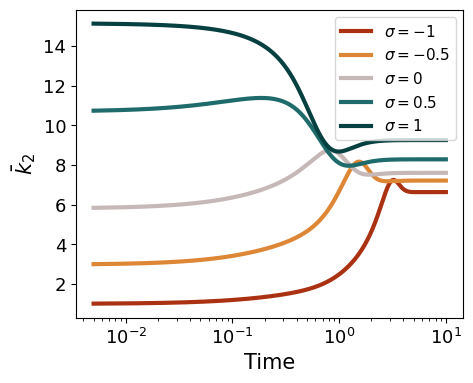

In [22]:
colors_1_ext = ['#4b0606','#780808', '#aa3111', '#dd8635', '#c7b8b8', '#63adab', '#1f6b6b', '#074040']
colors_1_short = ['#aa3111', '#dd8635', '#c7b8b8', '#1f6b6b', '#074040']
plt.figure(figsize=(5, 4))
j=0
for k in range(0,len(results_averk_new_infected_inter),2):
    plt.plot(results_averk_new_infected[k][-1][1:], results_averk_new_infected[k][1][1:],label=rf'$\sigma = {sigmas[k]}$',lw=3,color=colors_1_short[j])#,marker='o',ms=4)
    plt.ylabel(r'$\bar{k}_2$',fontsize=15)
    plt.xlabel('Time',fontsize=15)
    #plt.params(axis='both',labelsize=13)
    j+=1


plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xscale('log')
plt.legend(fontsize=11)

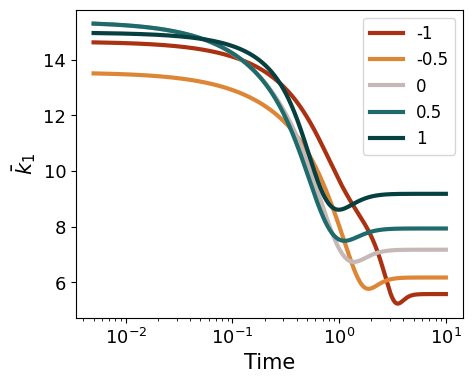

In [23]:
colors_1_ext = ['#4b0606','#780808', '#aa3111', '#dd8635', '#c7b8b8', '#63adab', '#1f6b6b', '#074040']
colors_1_short = ['#aa3111', '#dd8635', '#c7b8b8', '#1f6b6b', '#074040']
plt.figure(figsize=(5, 4))
j=0
for k in range(0,len(results_averk_new_infected),2):
    plt.plot(results_averk_new_infected[k][-1][1:], results_averk_new_infected[k][0][1:],label=sigmas[k],lw=3,color=colors_1_short[j])#marker='o',ms=5)
    plt.ylabel(r'$\bar{k}_1$',fontsize=15)
    plt.xlabel('Time',fontsize=15)
    #plt.params(axis='both',labelsize=13)
    j+=1


plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xscale('log')
plt.legend(fontsize=12)

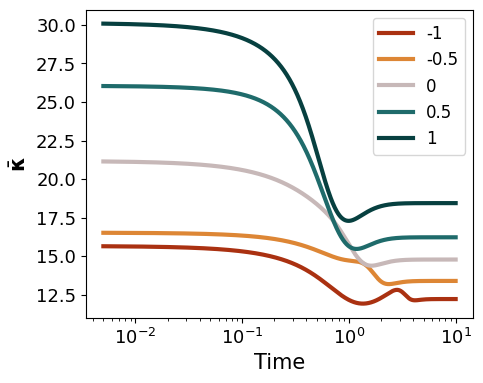

In [24]:
colors_1_ext = ['#4b0606','#780808', '#aa3111', '#dd8635', '#c7b8b8', '#63adab', '#1f6b6b', '#074040']
colors_1_short = ['#aa3111', '#dd8635', '#c7b8b8', '#1f6b6b', '#074040']
plt.figure(figsize=(5, 4))
j=0
for k in range(0,len(results_averk_new_infected),2):
    plt.plot(results_averk_new_infected[k][-1][1:], results_averk_new_infected[k][2][1:],label=sigmas[k],lw=3,color=colors_1_short[j])
    plt.ylabel(r'$\bar{\mathbf{\kappa}}$',fontsize=15)
    plt.xlabel('Time',fontsize=15)
    #plt.params(axis='both',labelsize=13)
    j+=1


plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xscale('log')
plt.legend(fontsize=12)

In [25]:
def get_participation_rate(results_per_net,t_ss):
    times_final, S_t_final, I_t_final, Motifs_time, Ik1k2, Ik1k2_states, I_new_time = results_per_net
    Y2_k1=[]
    Y2_k2=[]
    Y2_k12=[]
    states = Ik1k2_states[0]
    times_for_k_evol=[]
    delta=0.05
    c=1
    for i in range (1,len(Ik1k2)):
        if times_final[i]>t_ss:break

        I_k1k2=Ik1k2[i]
        #print(t_prev,times_final[i])
        #I_k1k2_prev=Ik1k2[i-1]
        Ik1={}
        Ik2={}
 
        for indx in range (len(states)):
            k1,k2=states[indx]
            if k1 not in Ik1.keys():
                Ik1[k1]=I_k1k2[indx]
            else: 
                Ik1[k1]+=I_k1k2[indx]

            if k2 not in Ik2.keys():
                Ik2[k2]=I_k1k2[indx]
            else: 
                Ik2[k2]+=I_k1k2[indx]
                    #print(k1,k2)

        w2_k1=0
        for k1 in Ik1.keys():
            w2_k1+=(Ik1[k1]/I_t_final[i])**2
            
        w2_k2=0
        for k2 in Ik2.keys():
            w2_k2+=(Ik2[k2]/I_t_final[i])**2

        w2_k12=0
        for indx in range (len(states)):
            w2_k12+=(I_k1k2[indx]/I_t_final[i])**2


        #print(w2_k1)
        times_for_k_evol.append(times_final[i])
        Y2_k1.append(w2_k1)
        Y2_k2.append(w2_k2)
        Y2_k12.append(w2_k12)

    return Y2_k1,Y2_k2,Y2_k12,times_for_k_evol

In [26]:
results_participation_rate=[]

for j in range(len(HO_networks)):
    results_ = get_participation_rate(results_per_net[j],t_ss)
    results_participation_rate.append(results_)


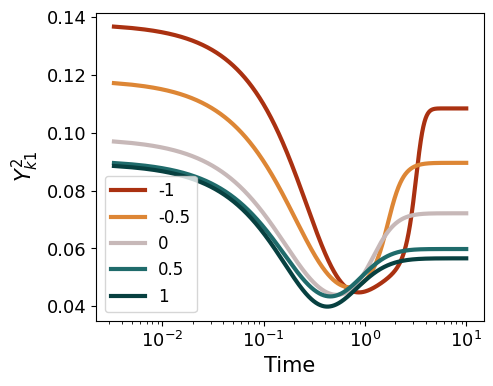

In [28]:
colors_1_ext = ['#4b0606','#780808', '#aa3111', '#dd8635', '#c7b8b8', '#63adab', '#1f6b6b', '#074040']
colors_1_short = ['#aa3111', '#dd8635', '#c7b8b8', '#1f6b6b', '#074040']
plt.figure(figsize=(5, 4))
j=0
for k in range(0,len(results_participation_rate),2):
    plt.plot(results_participation_rate[k][-1], results_participation_rate[k][0],label=sigmas[k],lw=3,color=colors_1_short[j])
    plt.ylabel(r'$Y^2_{k1}$',fontsize=15)
    plt.xlabel('Time',fontsize=15)
    #plt.params(axis='both',labelsize=13)
    j+=1

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xscale('log')
plt.legend(fontsize=12)

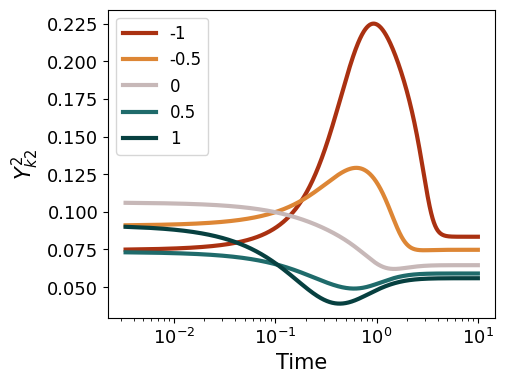

In [29]:
colors_1_ext = ['#4b0606','#780808', '#aa3111', '#dd8635', '#c7b8b8', '#63adab', '#1f6b6b', '#074040']
colors_1_short = ['#aa3111', '#dd8635', '#c7b8b8', '#1f6b6b', '#074040']
plt.figure(figsize=(5, 4))
j=0
for k in range(0,len(results_participation_rate),2):
    plt.plot(results_participation_rate[k][-1], results_participation_rate[k][1],label=sigmas[k],lw=3,color=colors_1_short[j])
    plt.ylabel(r'$Y^2_{k2}$',fontsize=15)
    plt.xlabel('Time',fontsize=15)
    #plt.params(axis='both',labelsize=13)
    j+=1


plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xscale('log')
plt.legend(fontsize=12)

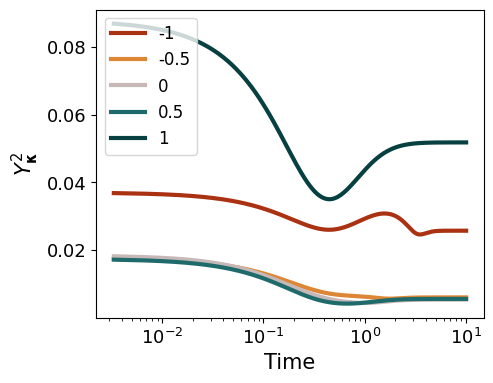

In [30]:
colors_1_ext = ['#4b0606','#780808', '#aa3111', '#dd8635', '#c7b8b8', '#63adab', '#1f6b6b', '#074040']
colors_1_short = ['#aa3111', '#dd8635', '#c7b8b8', '#1f6b6b', '#074040']
plt.figure(figsize=(5, 4))
j=0
for k in range(0,len(results_participation_rate),2):
    plt.plot(results_participation_rate[k][-1], results_participation_rate[k][2],label=sigmas[k],lw=3,color=colors_1_short[j])
    plt.ylabel(r'$Y^2_{\mathbf{\kappa}}$',fontsize=15)
    plt.xlabel('Time',fontsize=15)
    #plt.params(axis='both',labelsize=13)
    j+=1


plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xscale('log')
plt.legend(fontsize=12)

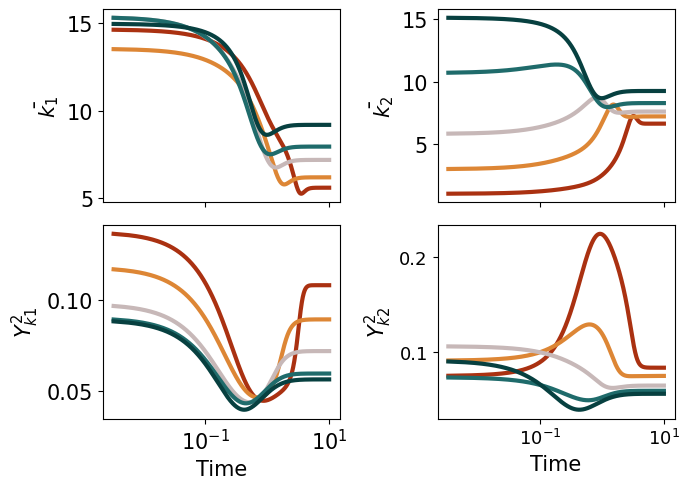

In [32]:
fig, ax = plt.subplots(2, 2, figsize=(7, 5))

linestyle_str = [ 
    'dashed', 
    'dotted', 
    'solid',
    'dashdot', 
    (0, (3, 5, 1, 5, 1, 5))  # custom dash-dot-dotted
]



l_styels=['solid','dashed', 'dotted', 'dashdot', '-..']
ms = ['o', 's', 'v', 'D', '^']


i=0
l=0
ylabels1=[r'$\bar{k_1}$',r'$\bar{k_2}$',r'$\bar{\mathbf{\kappa}}$']
for l in range(2):
    j=0
    for k in range(0,len(results_averk_new_infected),2):
        ax[i,l].plot(results_averk_new_infected[k][-1], results_averk_new_infected[k][l],label=sigmas[k],lw=3,color=colors_1_short[j])#ls=linestyle_str[j])
        ax[i,l].set_ylabel(ylabels1[l],fontsize=15)
        #ax[i,l].set_xlabel('Time',fontsize=15)
        #plt.params(axis='both',labelsize=13)
        j+=1
    
        ax[i,l].tick_params(axis='both', which='major', labelsize=15,labelbottom=False)
        ax[i,l].set_xscale('log')
        # if i==0 and l==1:
        #     ax[i,l].set_ylim((-2,27))





i=1
l=0
ylabels2=[r'$Y^2_{k1}$',r'$Y^2_{k2}$',r'$Y^2_{\mathbf{\kappa}}$']
for l in range(2):
    j=0
    for k in range(0,len(results_participation_rate),2):
        ax[i,l].plot(results_participation_rate[k][-1], results_participation_rate[k][l],label=sigmas[k],lw=3,color=colors_1_short[j])#ls=linestyle_str[j])
        ax[i,l].set_ylabel(ylabels2[l],fontsize=15)
        ax[i,l].set_xlabel('Time',fontsize=15)
        ax[i,l].tick_params(axis='both', which='major', labelsize=15)
        ax[i,l].set_xscale('log')
        # if i==1 and l==0:
        #     ax[i,l].set_ylim((0.045,0.1))

        j+=1



plt.tight_layout()
plt.subplots_adjust(bottom=0.2) 
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xscale('log')
#plt.legend(fontsize=12)


plt.tight_layout()

plt.savefig('fig5_new.pdf')

In [ ]:
bar_time1=[]
bar_time2=[]
states = Ik1k2_states[0]
times_for_k_evol=[]
deltat=0.2
c=1
t_prev=0
for i in range (1,len(Ik1k2)):
    Infect_degree1=[]
    Infect_degree2=[]
    if times_final[i]>3: break
    if times_final[i]>c*deltat:
        c+=1
        I_k1k2=Ik1k2[i]
        
        for indx in range (len(states)):
            k1,k2=states[indx]
            for l in range (int(I_k1k2[indx])):
                Infect_degree1.append(k1)
            for l in range (int(I_k1k2[indx])):
                Infect_degree2.append(k2)

    
        bar_time1.append(Infect_degree1)
        bar_time2.append(Infect_degree2)
        times_for_k_evol.append(times_final[i])

In [ ]:
print(len(bar_time1))

14


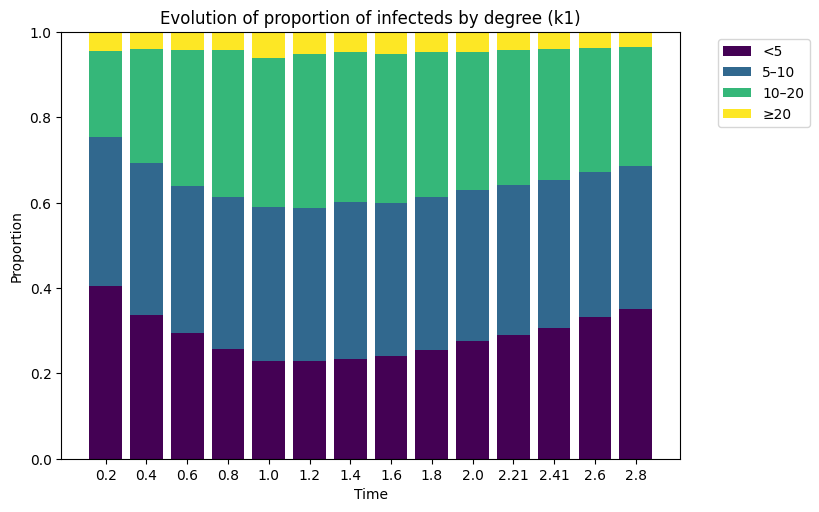

In [ ]:
data = bar_time1

# Define bin edges and labels
bins = [0, 5, 10, 20, np.inf]
labels = ["<5", "5–10", "10–20", "≥20"]

# Custom x labels (for example, times)
time_labels = []
for t in times_for_k_evol:
    time_labels.append(str(round(t,2))) # must match len(data)

# Compute proportions
proportions = []
for values in data:
    n = len(values)
    if n == 0:
        proportions.append([0] * (len(bins)-1))
        continue
    counts, _ = np.histogram(values, bins=bins)
    proportions.append(counts / n)

proportions = np.array(proportions)

# Colormap
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(labels)))

# Plot
time_steps = np.arange(len(data))
fig, ax = plt.subplots(figsize=(7, 5))

bottom = np.zeros(len(data))
for i, label in enumerate(labels):
    ax.bar(time_steps, proportions[:, i], bottom=bottom, 
           label=label, color=colors[i])
    bottom += proportions[:, i]

# Custom x-axis labels
ax.set_xticks(time_steps)
ax.set_xticklabels(time_labels)

# Formatting
ax.set_xlabel("Time")
ax.set_ylabel("Proportion")
plt.tight_layout()
ax.set_title("Evolution of proportion of infecteds by degree (k1)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax.set_ylim(0, 1)

plt.show()

Redo the bar plot by adding the expected proportions in the cummulative 

and/or plot them separtley 



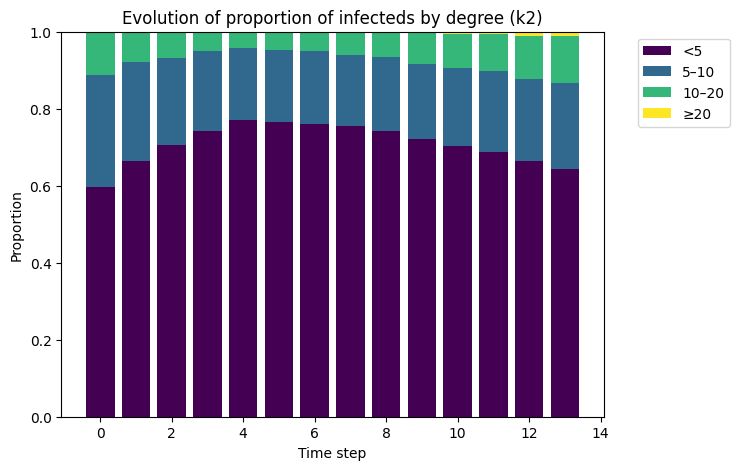

In [ ]:
data = bar_time2

# Define bin edges and labels
bins = [0, 5, 10, 20, np.inf]
labels = ["<5", "5–10", "10–20", "≥20"]

# Compute proportions for each category at each time step
proportions = []
for values in data:
    n = len(values)
    if n == 0:
        proportions.append([0] * (len(bins)-1))
        continue
    counts, _ = np.histogram(values, bins=bins)
    proportions.append(counts / n)

proportions = np.array(proportions)  # shape: (time_steps, num_categories)

# Pick a colormap
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(labels)))  # one color per category

# Plot stacked bars
time_steps = range(len(data))
fig, ax = plt.subplots(figsize=(7, 5))

bottom = np.zeros(len(data))
for i, label in enumerate(labels):
    ax.bar(time_steps, proportions[:, i], bottom=bottom, 
           label=label, color=colors[i])
    bottom += proportions[:, i]

# Formatting
ax.set_xlabel("Time step")
ax.set_ylabel("Proportion")
ax.set_title("Evolution of proportion of infecteds by degree (k2)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax.set_ylim(0, 1)

plt.show()


In [ ]:
def return_hyper_edges(sample_k1,sample_k2,N,check_conected=True):
    pairs,triples=configurational_model_hypergraph(sample_k1,sample_k2,N)
    
    hyper_edges_corr2=[*pairs, *triples]
    hyper_edges_separated_corr2=[pairs, triples]
    attempts=0

    while attempts<100:
        pairs,triples=configurational_model_hypergraph(sample_k1,sample_k2,N)
        G = nx.from_edgelist(pairs)

        is_connected = nx.is_connected(G)
        
        if check_conected==False: break

        if is_connected: break
        attempts+=1

    if attempts>100:
        print('exceeded attempts')
        return 
    
    hyper_edges=[*pairs, *triples]
        
    hyper_new=[]
    for edges in hyper_edges:
        new_edge=[]
        for ele in edges:
            new_edge.append(int(ele+1))
        hyper_new.append(np.array(new_edge))

    return hyper_edges, pairs, triples




In [ ]:
N=1000
k=[6,6]
var=[50,50]

r=[nb_r(k[0],var[0]),nb_r(k[1],var[1])]
p=[nb_p(k[0],var[0]),nb_p(k[1],var[1])]
print(r)
print(p)

sample_k1=np.random.negative_binomial(n=r[0], p=p[0],size=N)+1
sample_k2=np.random.negative_binomial(n=r[1], p=p[1],size=N)+1
print('')
print(sample_k1[0:5],sample_k1[-5:-1])
print(sample_k2[0:5],sample_k2[-5:-1])

he_uncorr = return_hyper_edges(sample_k1,sample_k2,N,check_conected=False)

sample_k1.sort()
sample_k2.sort()
print('')
print(sample_k1[0:5],sample_k1[-5:-1])
print(sample_k2[0:5],sample_k2[-5:-1])

he_corr1 = return_hyper_edges(sample_k1,sample_k2,N,check_conected=False)


sample_k1.sort()
sample_k2.sort()
sample_k2[::-1].sort()
print('')
print(sample_k1[0:5],sample_k1[-5:-1])
print(sample_k2[0:5],sample_k2[-5:-1])

he_corr2 = return_hyper_edges(sample_k1,sample_k2,N,check_conected=False)


sample_k1_poi=np.random.poisson(k[0],size=N)+1
sample_k2_poi=np.random.poisson(k[1],size=N)+1
print('')
print(sample_k1_poi[0:5],sample_k1_poi[-5:-1])
print(sample_k2_poi[0:5],sample_k2_poi[-5:-1])

he_poi = return_hyper_edges(sample_k1_poi,sample_k2_poi,N,check_conected=False)

Network_types=[ 'Homo' , 'Hete uncorrelated', 'Hete positive correlated ','Hete negative correlated ']
hyper_edges_list1 =[he_uncorr, he_corr1, he_corr2]

NameError: name 'nb_r' is not defined